In [1]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [2]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark = [], [], []

    for filename in filenames
        filename = pathdir*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark)
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark
end

function crop_imgs(imgs, x_crop, y_crop, mask)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop .* mask)
    end
    return imgs_crop
end

function mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)
    mask = zeros(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets_range)
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel)
        response = response .* droplet_radius^2
    end
    
    blobs = response .> threshold_droplets_range * std(img)^(1/2) # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

In [3]:
pathdir_date = "//DyLabNAS/Data/TwoDGas/2025/07/04"
dir_names_datasets = readdir(pathdir_date)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
dir_names_datasets = dir_names_datasets[10:end]
I_inc = [0.04, 0.1, 0.5, 3, 5.2, 6].*1e-3 # In W
I_sat = [0.5, 1, 5, 32, 56, 65] # Estimated saturation parameter
I_sat_range = [0:0.1:maximum(I_sat);]
τ_exp = [8, 7, 6, 5, 3, 2].*1e-6
x_crop = [1290:1560;]
y_crop = [1840:2210;]

λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_inc_range = [0.01:0.01:10;].*1e-3 # Intensity of the laser in W
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)

N_atoms_per_droplet = 15000

xc, yc, a, b, θ = 140, 200, 70, 40, 1.1;

### Create folders

In [ ]:
if !isdir("imgs")
    mkdir("imgs")
end
if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_"))
    mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_"))
end


if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/ODs_mask")
    mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/neg_ODs_mask")
    mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/neg_ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/droplets")
    mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/droplets")
end

for i = 1:length(dir_names_datasets)
    if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/ODs_mask/"*dir_names_datasets[i])
        mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/ODs_mask/"*dir_names_datasets[i])
    end

    if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/droplets/"*(dir_names_datasets[i]))
        mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/droplets/"*(dir_names_datasets[i]))
    end
    
    if !isdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/neg_ODs_mask/"*dir_names_datasets[i])
        mkdir("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/neg_ODs_mask/"*dir_names_datasets[i])
    end
end

# Import and crop the images

In [ ]:
imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets = [], [], []
mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

for dir_name_datasets in ProgressBar(dir_names_datasets)
    files_path = readdir(pathdir_date*"/"*dir_name_datasets)
    imgs_atoms, imgs_bkg, imgs_dark = load_imgs(files_path, pathdir_date*"/"*dir_name_datasets*"/")
    imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop = crop_imgs(imgs_atoms, x_crop, y_crop, mask), crop_imgs(imgs_bkg, x_crop, y_crop, mask), crop_imgs(imgs_dark, x_crop, y_crop, mask)
    push!(imgs_atoms_crop_datasets, imgs_atoms_crop), push!(imgs_bkg_crop_datasets, imgs_bkg_crop), push!(imgs_dark_crop_datasets, imgs_dark_crop)
end

In [ ]:
@save "Imgs_crop_mask.jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets

In [4]:
@load "Imgs_crop_mask.jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets;

# Compute the Intensities

In [15]:
I_atoms = imgs_atoms_crop_datasets ./ (0.85 * 0.107 * τ_exp)
I_bkg = imgs_bkg_crop_datasets ./ (0.85 * 0.107 * τ_exp)
I_dark = imgs_dark_crop_datasets ./ (0.85 * 0.107 * τ_exp);

In [16]:
@load "ODs_crop_mask.jld2" ODs_datasets;

# Count the droplets

In [17]:
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;]
threshold_droplets_range = 6000000
nbr_droplets = zeros((length(ODs_datasets), length(ODs_datasets[1])))
centers_droplets = []
save_imgs = false

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for idx_dataset in ProgressBar(1:length(ODs_datasets))
    centers_drop = []
    for (i, OD) in enumerate(ODs_datasets[idx_dataset])
        smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
        centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

        if save_imgs
            axs[1].imshow(smooth_norm_OD)
            axs[2].imshow(label_blobs)
            axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
            axs[3].imshow(OD)
            axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)

            savefig("imgs/"*join(split(pathdir_date, "/")[6:end], "_")*"/droplets/$(dir_names_datasets[idx_dataset])/$(i-1).png")
            for ax in axs
                ax.clear()
            end
        end

        nbr_droplets[idx_dataset, i] = length(centers)
        push!(centers_drop, centers)

    end
    push!(centers_droplets, centers_drop)
end

close("all")

0.0%┣                                                ┫ 0/6 [00:01<00:-7, -1s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:06<Inf:Inf, InfGs/it]
33.3%┣████████████████                                ┫ 2/6 [00:08<00:31, 8s/it]
50.0%┣████████████████████████                        ┫ 3/6 [00:09<00:14, 5s/it]
66.7%┣████████████████████████████████                ┫ 4/6 [00:11<00:07, 4s/it]
83.3%┣████████████████████████████████████████        ┫ 5/6 [00:13<00:03, 3s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:15<00:00, 3s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:15<00:00, 3s/it]


# Modelling one droplet

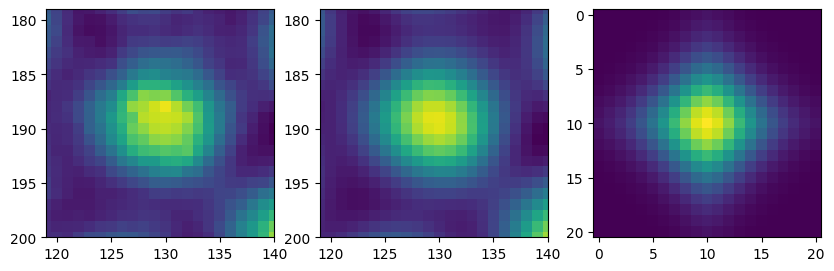

In [18]:
close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))
axs[1].imshow(ODs_datasets[end][1])
axs[1].set_xlim(119, 140)
axs[1].set_ylim(200, 179)

img_exp = axs[2].imshow(smooth_imgs(ODs_datasets[end][1], size_kernel_smooth))
axs[2].set_xlim(119, 140)
axs[2].set_ylim(200, 179)

x = -10:10
y = -10:10
radius_droplets = 10
z = exp.(-abs.((x' .* ones(length(y))) .+ 1im .* (ones(length(x))' .* y))^2/(2*radius_droplets^2))

axs[3].imshow(z)

# pygui(true); show()
pygui(false);

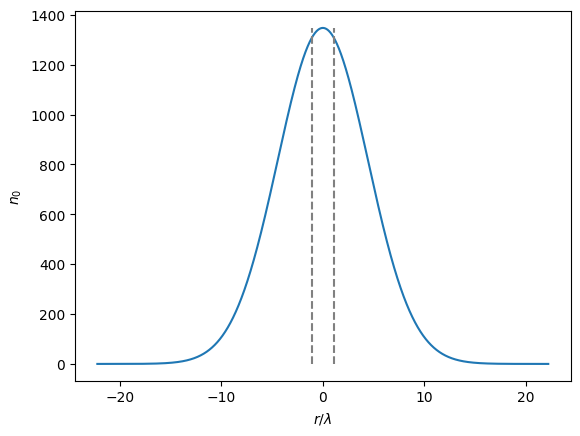

6408.279801318208

In [19]:
close("all")
fig = subplots()

N_atoms_per_droplet = 15000

radius_droplets_nomalised = radius_droplets*0.187e-6/λ
r = [-radius_droplets_nomalised*5:1e-2:radius_droplets_nomalised*5;]
plot(r, N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised) * exp.(-(r.^2)./(2*radius_droplets_nomalised^2)))

vlines(-size_kernel_smooth/2*0.187e-6/λ, 0, N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised), color="grey", linestyle="--")
vlines(size_kernel_smooth/2*0.187e-6/λ, 0, N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised), color="grey", linestyle="--")
xlabel(L"r/\lambda")
ylabel(L"n_0")
pygui(false)


smooth_kernel_r_range = [-size_kernel_smooth/2:1e-2:size_kernel_smooth/2;]
N_atoms_center_smooth = sum(N_atoms_per_droplet/(sqrt(2π)*radius_droplets_nomalised) * exp.(-(smooth_kernel_r_range.^2)./(2*radius_droplets_nomalised^2)).* 1e-2)

# Compute the intensity at the center of the droplets for each dataset

In [20]:
Sum_mean_Iatoms_center_drop = zeros((length(ODs_datasets), length(ODs_datasets[1])))
Sum_mean_Ibkg_center_drop = zeros((length(ODs_datasets), length(ODs_datasets[1])))
Sum_mean_Idark_center_drop = zeros((length(ODs_datasets), length(ODs_datasets[1])))

size_kernel_smooth = 5

for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
    for j in eachindex(ODs)
        centers_drops = centers_droplets[i][j]
        for d in eachindex(centers_drops)
            i_at = smooth_imgs(I_atoms[i][j], size_kernel_smooth)
            i_bkg = smooth_imgs(I_bkg[i][j], size_kernel_smooth)
            i_dark = smooth_imgs(I_dark[i][j], size_kernel_smooth)
            Sum_mean_Iatoms_center_drop[i, j] += i_at[round(Int, centers_drops[d][2]), round(Int, centers_drops[d][1])]
            Sum_mean_Ibkg_center_drop[i, j] += i_bkg[round(Int, centers_drops[d][2]), round(Int, centers_drops[d][1])]
            Sum_mean_Idark_center_drop[i, j] += i_dark[round(Int, centers_drops[d][2]), round(Int, centers_drops[d][1])]
        end
        Sum_mean_Iatoms_center_drop[i, j] /= nbr_droplets[i, j]
        Sum_mean_Ibkg_center_drop[i, j] /= nbr_droplets[i, j]
        Sum_mean_Idark_center_drop[i, j] /= nbr_droplets[i, j]

    end
end

Sum_mean_Iatoms_center_drop /= N_atoms_center_smooth
Sum_mean_Ibkg_center_drop /= N_atoms_center_smooth
Sum_mean_Idark_center_drop /= N_atoms_center_smooth;

0.0%┣                                                ┫ 0/6 [00:00<00:00, -0s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:02<Inf:Inf, InfGs/it]
33.3%┣████████████████                                ┫ 2/6 [00:04<00:15, 4s/it]
50.0%┣████████████████████████                        ┫ 3/6 [00:06<00:08, 3s/it]
66.7%┣████████████████████████████████                ┫ 4/6 [00:08<00:05, 3s/it]
83.3%┣████████████████████████████████████████        ┫ 5/6 [00:10<00:03, 3s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:12<00:00, 2s/it]
100.0%┣███████████████████████████████████████████████┫ 6/6 [00:12<00:00, 2s/it]


In [21]:
Mean_sum_mean_Iatoms_center_drop = vec(mean(Sum_mean_Iatoms_center_drop, dims=2))
Mean_sum_mean_Ibkg_center_drop = vec(mean(Sum_mean_Ibkg_center_drop, dims=2))
Mean_sum_mean_Idark_center_drop = vec(mean(Sum_mean_Idark_center_drop, dims=2))
Std_sum_mean_Iatoms_center_drop = vec(std(Sum_mean_Iatoms_center_drop, dims=2))
Std_sum_mean_Ibkg_center_drop = vec(std(Sum_mean_Ibkg_center_drop, dims=2))
Std_sum_mean_Idark_center_drop = vec(std(Sum_mean_Idark_center_drop, dims=2));

### Plot as a function of the lasers intensity

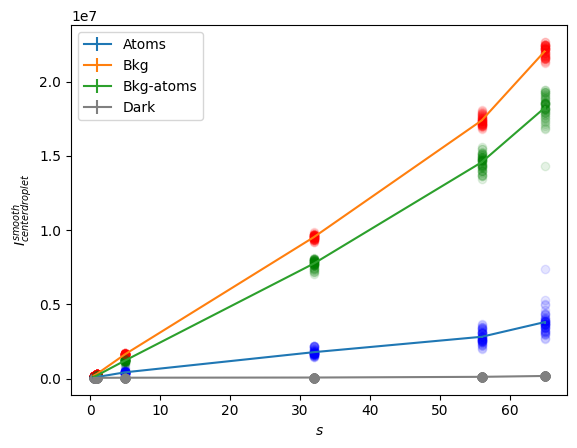

In [22]:
close("all")
fig = subplots()

errorbar(I_sat, Mean_sum_mean_Iatoms_center_drop, yerr=Std_sum_mean_Iatoms_center_drop/sqrt(length(ODs_datasets[1])), label="Atoms")
errorbar(I_sat, Mean_sum_mean_Ibkg_center_drop, yerr=Std_sum_mean_Ibkg_center_drop/sqrt(length(ODs_datasets[1])), label="Bkg")
errorbar(I_sat, Mean_sum_mean_Ibkg_center_drop-Mean_sum_mean_Iatoms_center_drop, yerr=vec(std(Sum_mean_Ibkg_center_drop-Sum_mean_Iatoms_center_drop, dims=2))/sqrt(length(ODs_datasets[1])), label="Bkg-atoms")
errorbar(I_sat, Mean_sum_mean_Idark_center_drop, yerr=Std_sum_mean_Idark_center_drop/sqrt(length(ODs_datasets[1])), label="Dark", color="grey")


for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j], color="b", alpha = 0.1)
        scatter(I_sat[i], Sum_mean_Ibkg_center_drop[i, j], color="r", alpha = 0.1)
        scatter(I_sat[i], Sum_mean_Ibkg_center_drop[i, j]-Sum_mean_Iatoms_center_drop[i, j], color="g", alpha = 0.1)
        scatter(I_sat[i], Sum_mean_Idark_center_drop[i, j], color="grey")
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

legend()

# pygui(true); show();
pygui(false);

In [25]:
maximum(Mean_sum_mean_Iatoms_center_drop)

3.7996981810549544e6

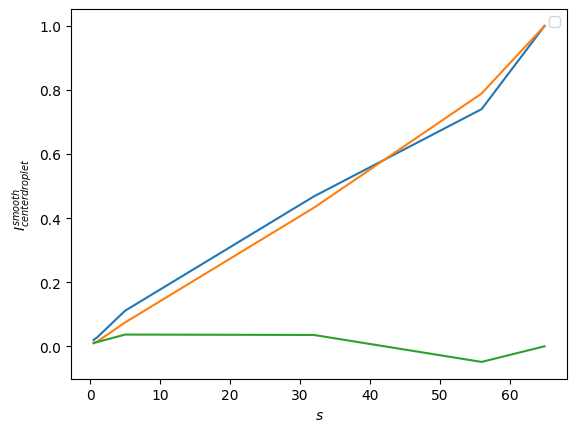

In [28]:
close("all")
fig = subplots()

# errorbar(I_sat, Mean_sum_mean_Iatoms_center_drop, yerr=Std_sum_mean_Iatoms_center_drop/sqrt(length(ODs_datasets[1])), label="Atoms")
# errorbar(I_sat, Mean_sum_mean_Ibkg_center_drop, yerr=Std_sum_mean_Ibkg_center_drop/sqrt(length(ODs_datasets[1])), label="Bkg")
# errorbar(I_sat, Mean_sum_mean_Ibkg_center_drop/maximum(Mean_sum_mean_Ibkg_center_drop)-Mean_sum_mean_Iatoms_center_drop, yerr=vec(std(Sum_mean_Ibkg_center_drop-Sum_mean_Iatoms_center_drop, dims=2))/sqrt(length(ODs_datasets[1])), label="Bkg-atoms")
# errorbar(I_sat, Mean_sum_mean_Idark_center_drop, yerr=Std_sum_mean_Idark_center_drop/sqrt(length(ODs_datasets[1])), label="Dark", color="grey")
plot(I_sat, Mean_sum_mean_Iatoms_center_drop/maximum(Mean_sum_mean_Iatoms_center_drop))
plot(I_sat, Mean_sum_mean_Ibkg_center_drop/maximum(Mean_sum_mean_Ibkg_center_drop))
plot(I_sat, Mean_sum_mean_Iatoms_center_drop/maximum(Mean_sum_mean_Iatoms_center_drop)-Mean_sum_mean_Ibkg_center_drop/maximum(Mean_sum_mean_Ibkg_center_drop))

# for (i, ODs) in enumerate(ODs_datasets)
#     for j in 1:length(ODs)
#         scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j], color="b", alpha = 0.1)
#         scatter(I_sat[i], Sum_mean_Ibkg_center_drop[i, j], color="r", alpha = 0.1)
#         scatter(I_sat[i], Sum_mean_Ibkg_center_drop[i, j]-Sum_mean_Iatoms_center_drop[i, j], color="g", alpha = 0.1)
#         scatter(I_sat[i], Sum_mean_Idark_center_drop[i, j], color="grey")
#     end
# end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

legend()

# pygui(true); show();
pygui(false);

### Nbr of droplets

In [ ]:
close("all")
fig = subplots()

errorbar(I_sat, vec(mean(nbr_droplets, dims=2)), yerr=vec(std(nbr_droplets, dims=2))/sqrt(length(ODs_datasets[1])))

for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], nbr_droplets[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"N_{droplets}")

# pygui(true); show();
pygui(false);

# Compare with simulations

In [ ]:
# Load simulations results
N_list = [30;]
r = 100
sat = [0:5:60;]
n0 = 1279
@load "C:/Users/Joschka/Desktop/Remy/Codes/SR_droplets/QuantumCumulants/Model17/Interacting_atoms_emission_box/Itot/Itot_N_$(N_list[1])_r_$(r)_sat_$(sat)_n0_$n0.jdl2" Itot nbr_error_t_N sat
Mean_Itot_sim = [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)]
Std_Itot_sim = [std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(sat)];

In [ ]:
close("all")
fig = subplots()

errorbar(I_sat, Mean_sum_mean_Iatoms_center_drop, yerr=Std_sum_mean_Iatoms_center_drop/sqrt(length(ODs_datasets[1])), label="Exp")
errorbar(sat, Mean_Itot_sim, yerr=Std_Itot_sim./sqrt.(r.-length.(nbr_error_t_N)), label="Sim")


for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j], color="b", alpha = 0.1)
    end
end

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j], alpha=0.1, color="red")
        end
    end
end

xlabel(L"s")
ylabel(L"$I_{center droplet}^{smooth}$ VS $I_{tot}$")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(I_sat, Mean_sum_mean_Iatoms_center_drop/maximum(Mean_sum_mean_Iatoms_center_drop), yerr=Std_sum_mean_Iatoms_center_drop/(maximum(Mean_sum_mean_Iatoms_center_drop)*sqrt(length(ODs_datasets[1]))), label="Exp")
errorbar(sat, Mean_Itot_sim/maximum(Mean_Itot_sim), yerr=Std_Itot_sim./(maximum(Mean_Itot_sim)*sqrt.(r.-length.(nbr_error_t_N))), label="Sim")


for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j]/maximum(Mean_sum_mean_Iatoms_center_drop), color="b", alpha = 0.1)
    end
end

for i in 1:length(sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(sat[i], Itot[i, j]/maximum(Mean_Itot_sim), alpha=0.1, color="red")
        end
    end
end

xlabel(L"s")
ylabel(L"$\mathcal{N}(I_{center droplet}^{smooth})$ VS $\mathcal{N}(I_{tot})$")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()
plot(I_sat, γ.*sqrt.(I_sat/2))
xlabel(L"s")
ylabel(L"$\Omega_{RO}$")

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
figure, axs = subplots(1, 2, figsize=(10, 5))
img1 = axs[1].imshow(imgs_atoms_crop_datasets[1][1], "plasma")
colorbar(img1)
img2 = axs[2].imshow(imgs_atoms_crop_datasets[end][1], "plasma")
colorbar(img2)
# pygui(true); show();
pygui(false);

In [ ]:
close("all")
figure, axs = subplots(1, 2, figsize=(10, 5))
img1 = axs[1].imshow(imgs_atoms_crop_datasets[1][1]-imgs_bkg_crop_datasets[1][1], "plasma")
colorbar(img1)
img2 = axs[2].imshow(imgs_atoms_crop_datasets[end][1]-imgs_bkg_crop_datasets[end][1], "plasma")
colorbar(img2)
# pygui(true); show();
pygui(false);

# Taking into account the exposure time

In [ ]:
close("all")
fig = subplots()

errorbar(I_sat, Mean_sum_mean_Iatoms_center_drop./τ_exp, yerr=Std_sum_mean_Iatoms_center_drop./(τ_exp*sqrt(length(ODs_datasets[1]))), label="Atoms")
errorbar(I_sat, Mean_sum_mean_Ibkg_center_drop./τ_exp, yerr=Std_sum_mean_Ibkg_center_drop./(τ_exp*sqrt(length(ODs_datasets[1]))), label="Bkg")
errorbar(I_sat, (Mean_sum_mean_Iatoms_center_drop-Mean_sum_mean_Ibkg_center_drop)./τ_exp, yerr=vec(std(Sum_mean_Iatoms_center_drop-Sum_mean_Ibkg_center_drop, dims=2))./(τ_exp*sqrt(length(ODs_datasets[1]))), label="Atoms-bkg")

for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j]/τ_exp[i], color="b", alpha = 0.1)
        scatter(I_sat[i], Sum_mean_Ibkg_center_drop[i, j]/τ_exp[i], color="r", alpha = 0.1)
        scatter(I_sat[i], (Sum_mean_Iatoms_center_drop[i, j]-Sum_mean_Ibkg_center_drop[i, j])/τ_exp[i], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

plot([0, maximum(I_sat_range)], [0, maximum(I_sat_range)*I_sat_cst], color="grey", linestyle="--", label=L"I_{inc}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

errorbar(I_sat, Mean_sum_mean_Iatoms_center_drop./(τ_exp*I_sat_cst), yerr=Std_sum_mean_Iatoms_center_drop./(τ_exp*I_sat_cst*sqrt(length(ODs_datasets[1]))), label="Atoms")

for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j]/(τ_exp[i]*I_sat_cst), color="b", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

legend()

# pygui(true); show();
pygui(false);

In [ ]:
close("all")
fig = subplots()

for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], Sum_mean_Iatoms_center_drop[i, j]/Sum_mean_Idark_center_drop[i, j], color="b", alpha = 0.1)
        scatter(I_sat[i], Sum_mean_Ibkg_center_drop[i, j]/Sum_mean_Idark_center_drop[i, j], color="r", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}^{smooth}")

suptitle(L"Normalising by $I_{dark}$")

# pygui(true); show();
pygui(false);

# Getting the real intensity